# Beaver Simulation - Boston Rumney Marsh

This notebook runs a multi-agent beaver simulation on real DEM (Digital Elevation Model) data.

## Quick Start Guide

1. **Run Cell 1**: Setup Python path
2. **Configure Cell 2**: Adjust parameters (see guide below)
3. **Run Cell 3**: Start simulation

## Parameter Guide

### Environment Parameters
- **File paths**: Point to DEM data (elevation, X/Y coordinates)
- **vegetation_quality_range**: `[min, max]` vegetation values (usually `[0, 10]`)
- **grass_growth_rate**: How fast vegetation grows (e.g., `1e-4` = 0.01% per hour)
- **grass_growth_interval**: `[min, max]` elevation where grass grows
- **streams_width**: Depth below 0 for water bodies (negative values = water)
- **river_growth_velocity**: How fast rivers deepen over time

### Robot (Beaver) Parameters
- **position**: `'random_home'` (near home), `'home'` (at home), or `[x, y]` coordinates
- **home_base_position**: `[[x, y]]` where beaver lodge is located (check `processing_metadata.json`)
- **range_x/y**: Random offset from home when using `'random_home'` (e.g., `[-3, 3]`)
- **maximum_load**: Max vegetation beaver can carry before returning home
- **harvest_threshold**: `[min, max]` vegetation quality to harvest (e.g., `[5, 10]`)
- **vegetation_removal**: Amount removed per harvest action
- **exploration_mode**: How beavers explore (e.g., `'gradient_D010'` = 10-cell neighborhood)
- **exploration_eta**: Exploration randomness (0=deterministic, 1=random)
- **exploration_map**: `'vegetation_quality'` or `'vegetation_visits'` guides exploration
- **n_traces**: Number of recent steps to remember for adaptive behavior
- **decay_values**: `[eta, threshold, load]` decay rates for adaptive learning

### Controller Parameters (Movement)
- **name**: `'P_repulsive'` (with terrain avoidance) or `'P'` (simple)
- **Kp, Kd, Ki**: PID controller gains (proportional, derivative, integral)
- **neighbourhood_size**: Cells around beaver to consider for repulsion
- **map_repulsive**: Map used for terrain avoidance

### Simulation Parameters
- **number_of_agents**: How many beavers to simulate
- **number_of_steps**: Total simulation time (in hours, e.g., `365*2` = 2 years)
- **downsampling**: Save frequency (e.g., `7*24` = weekly snapshots)
- **timedelta**: Time step size (1.0 = 1 hour per step)

---

In [1]:
# Setup: Add parent directory to Python path to import beaversim modules# Apply Gaussian blur to all images (increase/decrease sigma for stronger/weaker smoothing)
import sys
import os
from pathlib import Path
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
for parent in [cwd, *cwd.parents]:
    if (parent / 'beaversim').is_dir():
        project_root = parent
        break
else:
    raise RuntimeError("Could not locate project root containing 'beaversim'.")

project_root_str = str(project_root)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

print(f"Project root: {project_root}")
print(f"Python path updated to include: {project_root}")

Project root: /home/fedeoli/Documents/Work/Projects/beaverbot
Python path updated to include: /home/fedeoli/Documents/Work/Projects/beaverbot


In [2]:
from beaversim.scenarios.standard_beavers_scenario import standard_beavers_scenario

# ============================================================================
# BEAVER SIMULATION CONFIGURATION - RUMNEY MARSH, BOSTON
# ============================================================================

beavers_running_config = {
    # Agent-Environment coupling backend
    'backend_type': 'beavers_visualizer',
    
    # ========================================================================
    # ENVIRONMENT CONFIGURATION
    # ========================================================================
    'environment': {
        'name': 'beavers_environment',
        
        # --- Data Files (RGB outputs from utils/dem_conversion_interactive.ipynb) ---
        'elevation_file_path': '../../output/RumneyMarsh_Boston/DEM/elevation.npy',
        'latitude_file_path': '../../output/RumneyMarsh_Boston/DEM/latitude.npy',
        'longitude_file_path': '../../output/RumneyMarsh_Boston/DEM/longitude.npy',
        
        # --- Vegetation Dynamics ---
        'vegetation_quality_range': [0, 10],      # Min/max vegetation values
        'grass_growth_interval': [0, 8],          # Elevation range where grass grows
        'grass_growth_rate': 5e-4,                # Growth rate                
        'grass_growth_sigma': 1.0,                # Variability in growth (higher = more random)
        'mean_reversion_strength' : 0.0005,       # Strength of reversion towards seasonal average
        
        # --- Visitation Dynamics ---
        'visits_reset': 0.999,                    # decay factor for visit counts (0-1)
        
        # --- Water/River Dynamics ---
        'flow_info': {
            'river_growth_velocity': 1e-4,        # Rate rivers deepen over time
            'river_growth_interval': [-3, 0],     # Elevation range where rivers deepen            
            'streams_depth': 10,                  # Water depth (elevation < 0 = water)
            'direction': [0, 0],                  # Flow direction vector [x, y]
            'strength': 0.0,                      # Flow strength (affects beaver movement)            
        },
        
        'print': False,                           # Debug printing
    },
    
    # ========================================================================
    # BEAVER (ROBOT) CONFIGURATION
    # ========================================================================
    'robot': {   
        
        # --- Initial Position ---        
        'home_base_position': [[40, 20]],         # Lodge location (see processing_metadata.json)             
        
        # -- Agent Cognitive and Behavioral Parameters 
        'maximum_load': 1000,                     # Max load before returning home
        'harvest_interval': [3, 7],               # Only harvest vegetation in this range        
        'epsilon_greedy': 0.75,                   # Epsilon for epsilon-greedy exploration 
        'exploration_eta': [0.5],                 # Exploration randomness (0-1, higher = more random)
        'decay_values': [0, 0, 0],                # Adaptive decay [eta, harvest_interval, max_load]
        'role': 'explorer',                       # 'explorer', 'builder'
        
        # -- Dynamic Control and Model Parameters 
        'controller': {
            'name': 'P_repulsive',                # 'P_repulsive' includes terrain avoidance
            'Kp': 0.0,                            # Proportional gain
            'Kd': 0.0,                            # Derivative gain
            'Ki': 0.005,                          # Integral gain (primary for smooth movement)
            'neighbourhood_size': 2,              # Cells around beaver for repulsion
            'max': 2.0,                           # Max movement speed
            'accuracy': 1e-2,                     # Position accuracy threshold
            'dimension': 2,                       # 2D space
            'map_repulsive': 'vegetation_quality',  # Map for terrain avoidance
            'beta_repulsive': 0.5,                # Repulsion strength
        },
        # --- Physics Model ---
        'dynamics': {
            'name': 'integrator',                 # Simple integrator dynamics
            'mass': 1.0,
            'friction': 1.0,
        },
        
        # -- Environmental and Stigmergic Coupling Parameters 
        'vegetation_removal': 0,                  # Amount removed per harvest action
        'visit_increase': 1,                      # Increase in visit count per harvest action
        'exploration_map': 'vegetation_visits',   # Guide exploration by: 'vegetation_quality' or 'vegetation_visits'                                        
        
        # Miscellaneous                        
        'print': False,                           # Debug printing
    },
    
    # ========================================================================
    # SIMULATION CONFIGURATION
    # ========================================================================
    'simulation': {
        'seed': 20,                               # Random seed for reproducibility
        'timedelta': 1.0,                         # Time step size (hours)
        'schedule_policy': 'sequential',          # Agent execution order
        'gui': True,                              # Enable visualization
        'number_of_agents': 1,                    # Number of beavers
        'number_of_steps': 365 * 4,               # Total steps (2 years in hours)
        'downsampling': 14*24,                    # Save every 7 days (weekly)
        'save_path': 'output/rumney_marsh_rgb_a2',  # Where to save results
        'save_path': '../../output/simulations/rumney_marsh_demo',
        'print': True,                            # Print simulation progress
    },
}

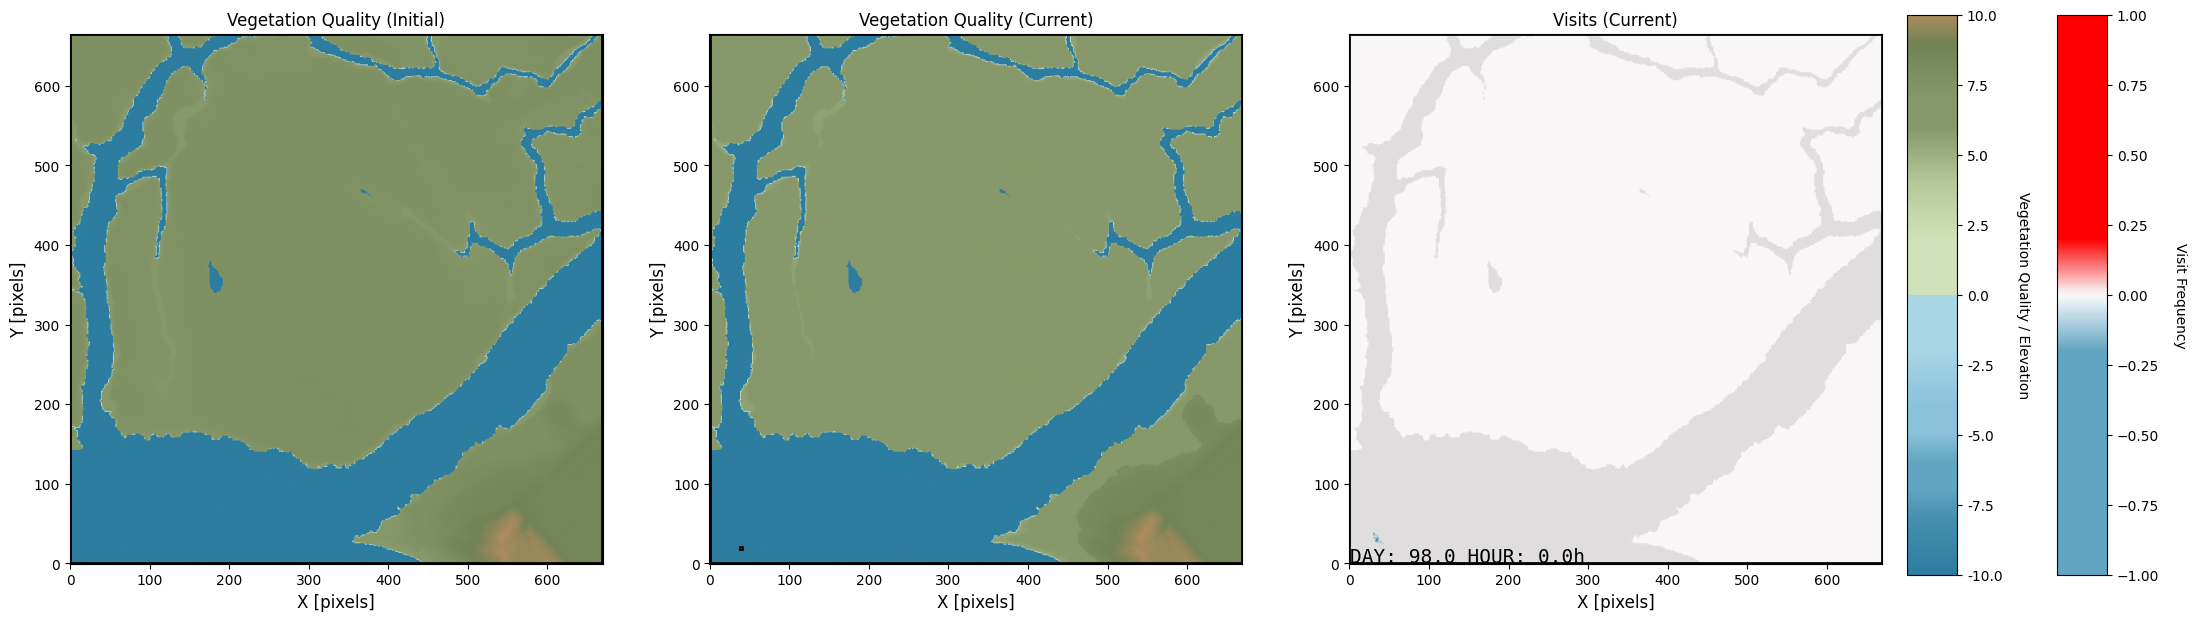

Environment map saved to: ../../output/simulations/rumney_marsh_demo/None_007.npy
Original map shape (environment format): (669, 665)
Saved map shape: (665, 669)
Original value range: [-10.000, 10.000]
Saved value range: [-1.000, 1.000]
[-10.000, 10.000] -> [-1.0, 1.0]
Applied inverse coordinate transformation for simulator compatibility


In [ ]:
back = standard_beavers_scenario(beavers_running_config)

In [ ]:
import matplotlib.pyplot as plt

stats = back._environment._growth_stats  # or replace 'env' with your environment variable

# Create a 2-row, 1-column layout, sharing the x-axis
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), sharex=True)

# ---------------------------------------------------------
# Top Subplot: Vegetation State (Integrator Output)
# ---------------------------------------------------------
ax1.plot(stats['day'], stats['veg_mean'], label='Vegetation Mean', color='green')
ax1.fill_between(stats['day'],
                 [m - s for m, s in zip(stats['veg_mean'], stats['veg_std'])],
                 [m + s for m, s in zip(stats['veg_mean'], stats['veg_std'])],
                 color='green', alpha=0.2, label='Mean ± Std')

ax1.set_ylabel('Vegetation Value', fontsize=20)
ax1.set_title('Macroscopic Vegetation State Over Time', fontsize=20)
ax1.tick_params(axis='y', labelsize=15)
ax1.legend(loc='upper right', fontsize=15) # Moved inside for cleaner margins
ax1.grid(True)

# ---------------------------------------------------------
# Bottom Subplot: Growth Rates (System Inputs/Derivatives)
# ---------------------------------------------------------
ax2.plot(stats['day'], stats['growth_factor_mean'], label='Effective Growth Mean', color='blue', linestyle='--')
ax2.fill_between(stats['day'],
                 [m - s for m, s in zip(stats['growth_factor_mean'], stats['growth_factor_std'])],
                 [m + s for m, s in zip(stats['growth_factor_mean'], stats['growth_factor_std'])],
                 color='blue', alpha=0.2)

ax2.plot(stats['day'], stats['random_growth_mean'], label='Stochastic Component', color='orange', linestyle='--')
ax2.fill_between(stats['day'],
                 [m - s for m, s in zip(stats['random_growth_mean'], stats['random_growth_std'])],
                 [m + s for m, s in zip(stats['random_growth_mean'], stats['random_growth_std'])],
                 color='orange', alpha=0.2)

ax2.set_xlabel('Simulation Day', fontsize=20)
ax2.set_ylabel('Growth Rate ($\Delta v$)', fontsize=20)
ax2.set_title('Seasonal Drive and Stochastic Growth Factors', fontsize=20)

# X-axis formatting (shared across both)
ax2.set_xlim(0, max(stats['day']))
ax2.set_xticks(range(0, max(stats['day']) + 1, 180))  # Ticks every 6 months (180 days)
ax2.tick_params(axis='both', labelsize=15)
ax2.legend(loc='upper right', fontsize=15)
ax2.grid(True)

# Adjust layout to prevent overlap and display
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import beaversim.ral.backend.modules.module_colors as cm
import re

def extract_index(filename):
    match = re.search(r'_(\d+)\.npy$', filename)
    return int(match.group(1)) if match else None

# colormaps
cmap_instance = cm.ColorMaps()

# downsampling
downsampling = beavers_running_config.get('simulation').get('downsampling')

# Paths to your 4 .npy files (update these if needed)
snapshots = [
    '../../output/simulations/rumney_marsh_demo/None_000.npy',
    '../../output/simulations/rumney_marsh_demo/None_006.npy',
    '../../output/simulations/rumney_marsh_demo/None_012.npy',
    '../../output/simulations/rumney_marsh_demo/None_018.npy',
    '../../output/simulations/rumney_marsh_demo/None_024.npy'
]

# Load the 4 snapshots
maps = [np.load(path) for path in snapshots]
indices = [extract_index(path) for path in snapshots]

# Set up the plot
fig, axes = plt.subplots(1, 5, figsize=(30, 4.6), sharey=True)
vmin = min(m.min() for m in maps)
vmax = max(m.max() for m in maps)

for i, (ax, m) in enumerate(zip(axes, maps)):
    im = ax.imshow(m, origin='lower', cmap=cmap_instance._bluebrowngreen_colormap, vmin=vmin, vmax=vmax)
    ax.set_title(f"Day {indices[i]*downsampling/24:.0f}", fontsize=20)
    ax.set_xlabel('X [m]', fontsize=20)
    ax.tick_params(axis='both', labelsize=15)
    if i == 0:
        ax.set_ylabel('Y [m]', fontsize=20)    

# Only add colorbar to the last axis
cbar = fig.colorbar(im, ax=axes[-1], fraction=0.046, pad=0.04, shrink=0.9)
cbar.set_label('Vegetation/Elevation', fontsize=20)
cbar.ax.tick_params(labelsize=15)

plt.tight_layout()
plt.show()